# TS4 (Estimación espectral: desparramo)

Senoidal de potencia unitaria con desintonía respecto a la grilla de la DFT, `f0 = k0·Δf`. Se analizan:
- PSD para `k0 = {N/4, N/4 + 0.25, N/4 + 0.5}` y el efecto del desparramo espectral (spectral leakage)
- Verificación de potencia unitaria (Parseval)
- Zero padding como interpolación del espectro

Nota: ver conclusiones al final.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
fs  = 1000               # Hz, frecuencia de muestreo
N   = 1000               # muestras totales
df  = fs / N             # Hz, resolución espectral Δf = 1 Hz
A   = np.sqrt(2)         # amplitud → P = A²/2 = 1 W

# Desintonías respecto a Δf:  f0 = k0 · Δf
k0_values = [N / 4, N / 4 + 0.25, N / 4 + 0.5]
colors    = ['steelblue', 'orangered', 'seagreen']

t = np.arange(N) / fs

## PSD


In [2]:
def psd(x, nfft):
    """PSD normalizada tal que sum(psd) = potencia media de x (Parseval)."""
    X = np.fft.fft(x, nfft)
    return np.abs(X) ** 2 / (N * nfft)

## Densidades espectrales (desintonía)


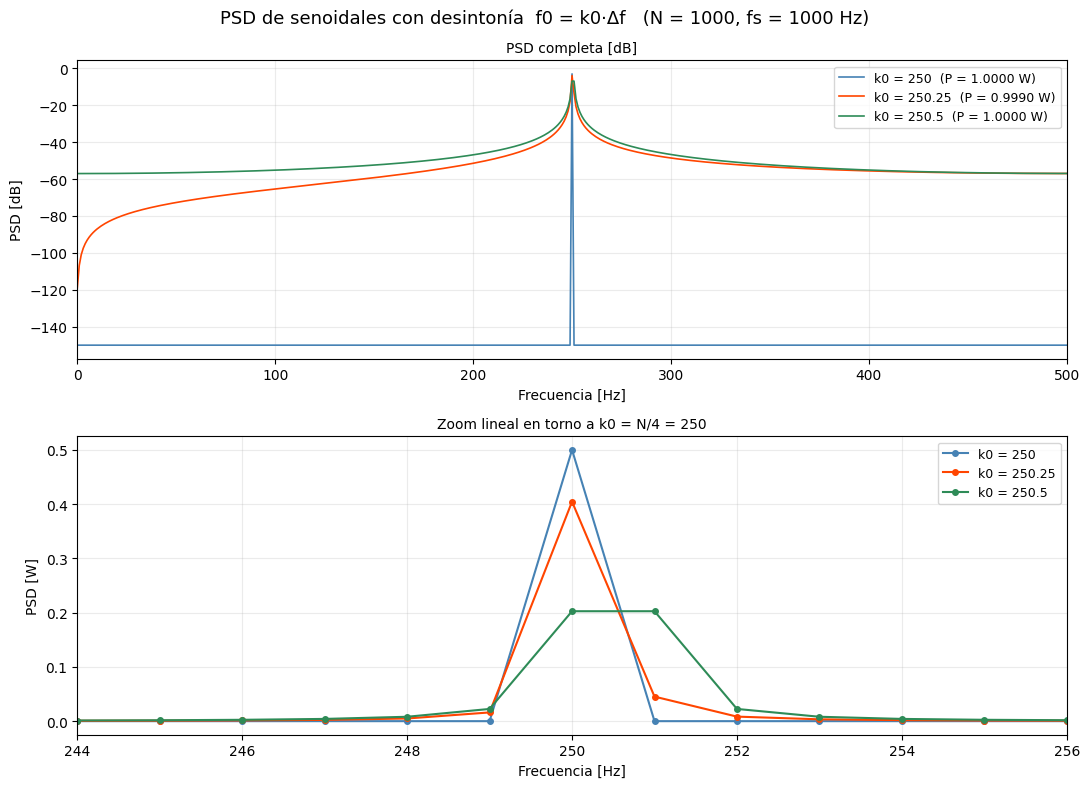

In [3]:
fig1, axes1 = plt.subplots(2, 1, figsize=(11, 8))
fig1.suptitle(
    'PSD de senoidales con desintonía  f0 = k0·Δf   (N = 1000, fs = 1000 Hz)',
    fontsize=13
)

freqs = np.arange(N) * df

for k0, c in zip(k0_values, colors):
    f0 = k0 * df
    x  = A * np.sin(2 * np.pi * f0 * t)
    P  = psd(x, N)

    axes1[0].plot(freqs, 10 * np.log10(P + 1e-15), color=c, lw=1.2,
                  label=f'k0 = {k0:g}  (P = {np.sum(P):.4f} W)')
    axes1[1].plot(freqs, P, color=c, lw=1.5, marker='o', ms=4,
                  label=f'k0 = {k0:g}')

axes1[0].set_title('PSD completa [dB]', fontsize=10)
axes1[0].set_xlabel('Frecuencia [Hz]')
axes1[0].set_ylabel('PSD [dB]')
axes1[0].set_xlim(0, fs / 2)
axes1[0].legend(fontsize=9)
axes1[0].grid(True, alpha=0.25)

axes1[1].set_title('Zoom lineal en torno a k0 = N/4 = 250', fontsize=10)
axes1[1].set_xlabel('Frecuencia [Hz]')
axes1[1].set_ylabel('PSD [W]')
axes1[1].set_xlim(244, 256)
axes1[1].legend(fontsize=9)
axes1[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Verificación de potencia


In [4]:
print(f"{'k0':>10}  {'f0 [Hz]':>10}  {'P [W]':>10}")
for k0 in k0_values:
    f0 = k0 * df
    x  = A * np.sin(2 * np.pi * f0 * t)
    P  = psd(x, N)
    print(f"{k0:>10g}  {f0:>10.2f}  {np.sum(P):>10.6f}")

        k0     f0 [Hz]       P [W]
       250      250.00    1.000000
    250.25      250.25    0.999000
     250.5      250.50    1.000000


## Zero padding


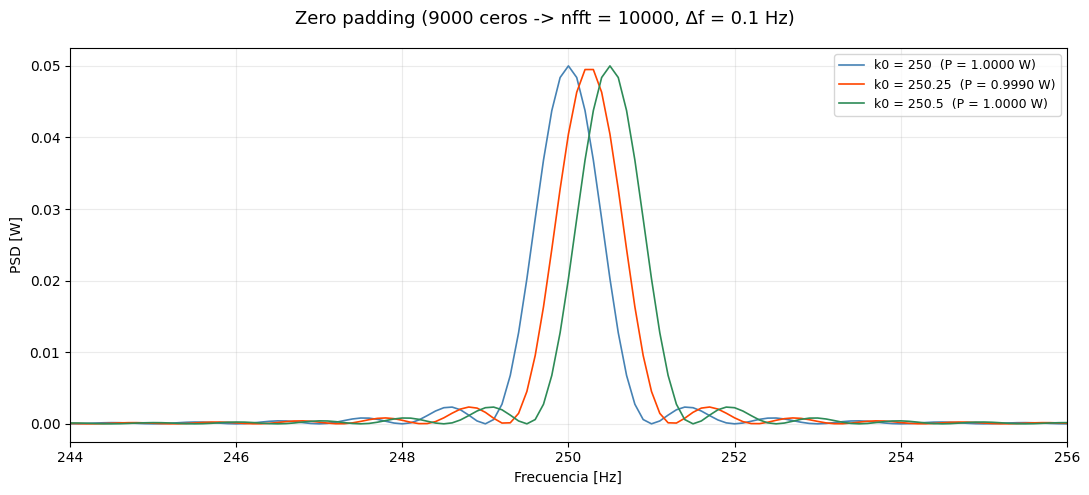

In [5]:
nfft     = 10 * N
df_zp    = fs / nfft
freqs_zp = np.arange(nfft) * df_zp

fig2, ax2 = plt.subplots(figsize=(11, 5))
fig2.suptitle(
    f'Zero padding ({9*N} ceros -> nfft = {nfft}, Δf = {df_zp:g} Hz)',
    fontsize=13
)

for k0, c in zip(k0_values, colors):
    f0   = k0 * df
    x    = A * np.sin(2 * np.pi * f0 * t)   # señal original de N muestras
    P_zp = psd(x, nfft)                     # fft con relleno de ceros

    ax2.plot(freqs_zp, P_zp, color=c, lw=1.2,
             label=f'k0 = {k0:g}  (P = {np.sum(P_zp):.4f} W)')

ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [W]')
ax2.set_xlim(244, 256)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Conclusiones

**a)**

Cuando la frecuencia de la senoidal cae exactamente sobre una línea de la grilla (k0 = N/4), toda la energía se concentra en un único bin y la PSD muestra un pico perfectamente definido. Al agregar una desintonía de 0.25 o 0.5 veces delta f, la energía se "desparrama" hacia los bins vecinos. El caso más crítico es la desintonía de 0.5 * delta f (justo entre dos líneas de la grilla), donde el desparramo es máximo y el espectro pierde nitidez notablemente.

**b)**

En todos los casos la suma de la PSD resultó igual a 1 W, verificando la potencia unitaria por el teorema de Parseval. La razón por la cual dos senoidales de frecuencias muy similares pueden tener espectros tan distintos es que la DFT asume implícitamente que la señal es periódica dentro de la ventana de N muestras. Si la frecuencia no es un múltiplo exacto de delta f, la señal no completa un número entero de ciclos en esa ventana, generando una discontinuidad en los bordes que introduce componentes espectrales espurias en todos los demás bins.

**Bonus**

El zero padding (9N ceros agregados, nfft = 10N) no mejora la resolución espectral real, esta sigue determinada únicamente por la longitud de la señal original. Lo que hace es interpolar el espectro continuo subyacente con mayor densidad de puntos, revelando la forma del lóbulo de la función ventana rectangular. Con esto se puede apreciar con más detalle cómo se distribuye la energía en cada caso de desintonía, pero no es posible separar componentes que estén a menos de delta f entre sí.